# CalmFruits — неделя 1: аудит данных и EDA

Цель тетради — доказательно изучить сырой каталог и тренировочную разметку до моделирования. Здесь не создаются поисковые индексы, golden-set, split для обучения или метрики; `queries_synthetic_test.parquet` не читается.

Каждый вывод в рабочем документе следует делать только после расположенной выше выполненной ячейки с соответствующей таблицей или графиком.

In [1]:
from __future__ import annotations

import importlib.metadata
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src' / 'calmfruits').exists(), 'Run from the repository root or notebooks/ directory.'
sys.path.insert(0, str(ROOT / 'src'))

from calmfruits.data import EDA_SOURCE_FILES, load_local_env, read_eda_sources
from calmfruits.eda import (
    as_clean_string,
    color_mentioned_in_name,
    contains_article_like_token,
    contains_html,
    contains_special_symbols,
    diagnostic_product_text,
    join_text_fields,
    missing_profile,
    select_mvp_root_categories,
    text_length_profile,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
ARTIFACT_DIR = ROOT / 'artifacts' / 'eda'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
dotenv_found = load_local_env(ROOT / '.env')

environment_report = pd.Series({
    'python': sys.version.split()[0],
    'pandas': importlib.metadata.version('pandas'),
    'numpy': importlib.metadata.version('numpy'),
    'pyarrow': importlib.metadata.version('pyarrow'),
    'boto3': importlib.metadata.version('boto3'),
    'matplotlib': importlib.metadata.version('matplotlib'),
    'seaborn': importlib.metadata.version('seaborn'),
    'seed': SEED,
    'device': 'CPU',
    'repository_root': str(ROOT),
    'artifact_directory': str(ARTIFACT_DIR),
    'allowed_week_1_sources': ', '.join(sorted(EDA_SOURCE_FILES)),
    'local_dotenv_detected': dotenv_found,
})
display(environment_report.to_frame('value'))


,value
python,3.12.6
pandas,2.2.3
numpy,1.26.4
pyarrow,24.0.0
boto3,1.43.36
matplotlib,3.9.4
seaborn,0.13.2
seed,42
device,CPU
repository_root,/Users/dkunicyn/Documents/to-future/calm-fruit


## 1. Загрузка разрешённых источников

Загружаем только сырой каталог и тренировочную разметку напрямую из S3. Учётные данные не выводятся. Если `.env` отсутствует, перед запуском экспортируйте переменные из `.env.example` в окружение либо создайте локальный игнорируемый `.env`.

In [2]:
products_raw, queries_train = read_eda_sources()

PRODUCT_COLUMNS = {
    'imt_id', 'nm_id', 'imt_name', 'subj_name', 'subj_root_name',
    'nm_colors_names', 'vendor_code', 'description', 'brand_name',
}
QUERY_COLUMNS = {'query_id', 'query_text', 'item_id', 'relevance'}
assert PRODUCT_COLUMNS.issubset(products_raw.columns), products_raw.columns.tolist()
assert QUERY_COLUMNS.issubset(queries_train.columns), queries_train.columns.tolist()
assert products_raw['imt_id'].notna().all() and products_raw['nm_id'].notna().all()
assert queries_train['query_id'].notna().all() and queries_train['item_id'].notna().all()

source_inventory = pd.DataFrame({
    'dataset': ['wb_products_raw_sample.parquet', 'queries_synthetic_train.parquet'],
    'rows': [len(products_raw), len(queries_train)],
    'columns': [products_raw.shape[1], queries_train.shape[1]],
})
display(source_inventory)
display(products_raw.dtypes.rename('dtype').to_frame())
display(queries_train.dtypes.rename('dtype').to_frame())


,dataset,rows,columns
0,wb_products_raw_sample.parquet,200000,9
1,queries_synthetic_train.parquet,11453,4


,dtype
imt_id,int64
nm_id,int64
imt_name,object
subj_name,object
subj_root_name,object
nm_colors_names,object
vendor_code,object
description,object
brand_name,object


,dtype
query_id,object
query_text,object
item_id,int64
relevance,int64


## 2. Структура каталога и дубликаты

Проверяем, какой объект описывает строка, как `nm_id` соотносится с `imt_id`, и есть ли полные или ключевые дубликаты. Вывод о будущей дедупликации будет основан на этой таблице.

In [3]:
catalog_structure = pd.Series({
    'rows': len(products_raw),
    'unique_imt_id': products_raw['imt_id'].nunique(),
    'unique_nm_id': products_raw['nm_id'].nunique(),
    'complete_duplicate_rows': int(products_raw.duplicated().sum()),
    'duplicate_imt_rows_after_first': int(products_raw.duplicated('imt_id').sum()),
    'duplicate_nm_rows_after_first': int(products_raw.duplicated('nm_id').sum()),
}).to_frame('value')
variants_per_card = products_raw.groupby('imt_id')['nm_id'].nunique().rename('nm_per_imt')
assert variants_per_card.index.is_unique
display(catalog_structure)
display(variants_per_card.describe(percentiles=[.5, .9, .95, .99]).to_frame('nm_per_imt'))

attribute_conflicts = (
    products_raw.groupby('imt_id')[['imt_name', 'subj_name', 'subj_root_name', 'description']]
    .nunique(dropna=False)
    .gt(1)
    .sum()
    .rename('imt_id_with_more_than_one_value')
    .to_frame()
)
display(attribute_conflicts)


,value
rows,200000
unique_imt_id,174427
unique_nm_id,199957
complete_duplicate_rows,0
duplicate_imt_rows_after_first,25573
duplicate_nm_rows_after_first,43


,nm_per_imt
count,174427.000000
mean,1.146365
std,0.876291
min,1.000000
50%,1.000000
90%,1.000000
95%,2.000000
99%,5.000000
max,30.000000


,imt_id_with_more_than_one_value
imt_name,1606
subj_name,12
subj_root_name,0
description,1274


**Вывод по `catalog_structure`, `variants_per_card` и `attribute_conflicts`.** В 200 000 строках 174 427 уникальных карточек `imt_id`; 25 573 строки повторяют карточку, поэтому индексировать варианты `nm_id` нельзя. Полных дубликатов нет, но внутри части `imt_id` отличаются `imt_name` (1 606) и `description` (1 274), поэтому на следующей неделе строку для карточки нужно выбирать детерминированно, отдавая приоритет наиболее информативному непустому описанию.

## 3. Полнота текстовых и категориальных полей

Пустая строка и строка из пробелов считаются пропуском так же, как `NaN`. Отдельно измеряем строгий входной критерий MVP из `AGENTS.md`: для будущего индекса обязательны заполненные `imt_name` **и** `description`.

In [4]:
TEXT_AND_CATEGORY_COLUMNS = [
    'imt_name', 'description', 'nm_colors_names', 'subj_name', 'subj_root_name', 'brand_name',
]
products_missing = missing_profile(products_raw, TEXT_AND_CATEGORY_COLUMNS)
display(products_missing.style.format({'missing_share': '{:.2%}'}))

name_present = as_clean_string(products_raw['imt_name']).notna()
description_present = as_clean_string(products_raw['description']).notna()
strict_indexability = pd.Series({
    'rows_with_name_and_description': int((name_present & description_present).sum()),
    'share_with_name_and_description': float((name_present & description_present).mean()),
    'rows_missing_name_or_description': int((~(name_present & description_present)).sum()),
}).to_frame('value')
display(strict_indexability)


,null_count,blank_count,whitespace_count,missing_total,missing_share
column,,,,,
imt_name,0,708,0,708,0.35%
description,0,57500,9,57509,28.75%
nm_colors_names,0,34226,0,34226,17.11%
subj_name,0,8,0,8,0.00%
subj_root_name,0,8,0,8,0.00%
brand_name,0,201,0,201,0.10%


,value
rows_with_name_and_description,141946.00000
share_with_name_and_description,0.70973
rows_missing_name_or_description,58054.00000


**Вывод по `products_missing` и `strict_indexability`.** Описание отсутствует в 57 509 строках (28,75%), тогда как пустое название встречается редко (708 строк, 0,35%). По строгому правилу проекта в будущий индекс войдут только 141 946 строк (70,97%) с обоими текстовыми полями; 58 054 строки будут исключены и это сокращение каталога нужно показать в baseline.

## 4. Категории

Изучаем распределение на уровне строк и уникальных карточек. Первая визуализация показывает размер потенциальных доменов, а таблица редких предметных категорий — хвост распределения.

,rows
subj_root_name,
Одежда,43316
Аксессуары,16446
Дом,15024
Обувь,13187
Красота,9895
Посуда и инвентарь,7799
Смартфоны и аксессуары,6997
Белье,6066
Игрушки,5411


,unique_imt_id
subj_root_name,
Одежда,36965
Дом,13482
Аксессуары,13230
Обувь,11524
Красота,9152
Посуда и инвентарь,7246
Смартфоны и аксессуары,5558
Игрушки,4944
Белье,4795


,unique_imt_id
subj_name,
Секундомеры,1
Камеры для коптеров,1
Казу,1
Сетки затеняющие,1
Йо-йо,1
Сигнализации автомобильные,1
Сигналы звуковые пневмо-электрические,1
Источники питания,1
Ионизаторы серебряные,1


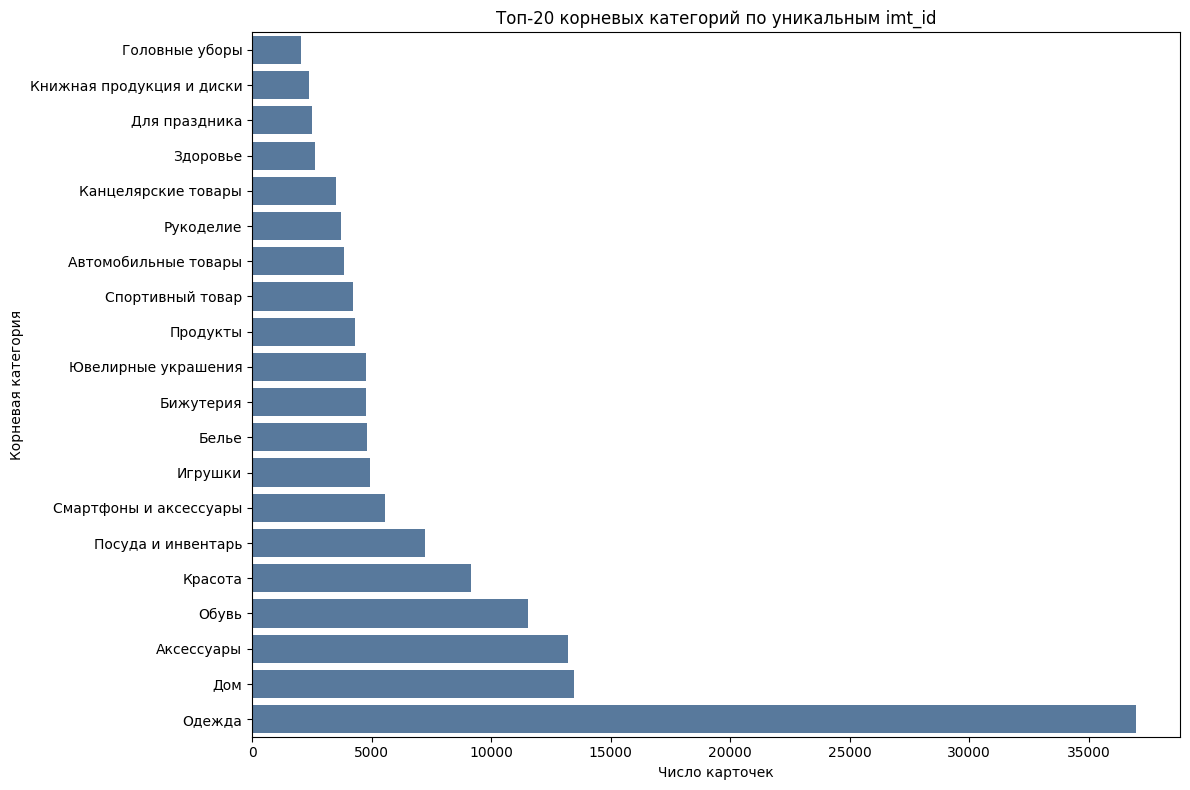

In [5]:
root_category_rows = products_raw['subj_root_name'].value_counts(dropna=False).rename('rows').to_frame()
root_category_imt = (
    products_raw.assign(subj_root_name=as_clean_string(products_raw['subj_root_name']))
    .dropna(subset=['subj_root_name'])
    .groupby('subj_root_name')['imt_id'].nunique().rename('unique_imt_id').sort_values(ascending=False).to_frame()
)
subj_category_imt = (
    products_raw.assign(subj_name=as_clean_string(products_raw['subj_name']))
    .dropna(subset=['subj_name'])
    .groupby('subj_name')['imt_id'].nunique().rename('unique_imt_id').sort_values(ascending=False)
)
display(root_category_rows.head(20))
display(root_category_imt.head(20))
display(subj_category_imt.tail(20).to_frame())

plot_data = root_category_imt.head(20).sort_values('unique_imt_id')
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=plot_data.reset_index(), y='subj_root_name', x='unique_imt_id', ax=ax, color='#4C78A8')
ax.set(title='Топ-20 корневых категорий по уникальным imt_id', xlabel='Число карточек', ylabel='Корневая категория')
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'root_categories_by_imt.png', dpi=150, bbox_inches='tight')
plt.show()


**Вывод по `root_category_rows`, `root_category_imt`, `subj_category_imt`.** Каталог неоднороден: крупнейшие корни по строкам — «Одежда» (43 316), «Аксессуары» (16 446), «Дом» (15 024) и «Обувь» (13 187), а в хвосте предметных категорий есть отдельные карточки. Значит, MVP следует ограничить доменом и не переносить на редкие категории выводы из крупных без отдельной проверки.

## 5. Длины текстов

Измеряем длины в символах и словах. Распределение и экстремальные карточки понадобятся на второй неделе при выборе эмбеддера и политики очистки/обрезки текста.

count       mean         std  min    1%    5%  \
imt_name    characters  199292.0  32.968694     23.9208  1.0   4.0   5.0   
            words       199292.0   4.819215    3.637775  1.0   1.0   1.0   
description characters  142491.0  522.09096  485.182015  1.0  46.0  68.0   
            words       142491.0  70.720375   66.458342  1.0   6.0   9.0   

                          25%    50%    75%     95%     99%     max  
imt_name    characters    9.0   31.0   49.0    81.0    97.0   121.0  
            words         1.0    4.0    7.0    12.0    15.0    31.0  
description characters  195.0  398.0  731.5  1324.0  2353.0  5000.0  
            words        26.0   53.0   97.0   188.0   321.0   754.0

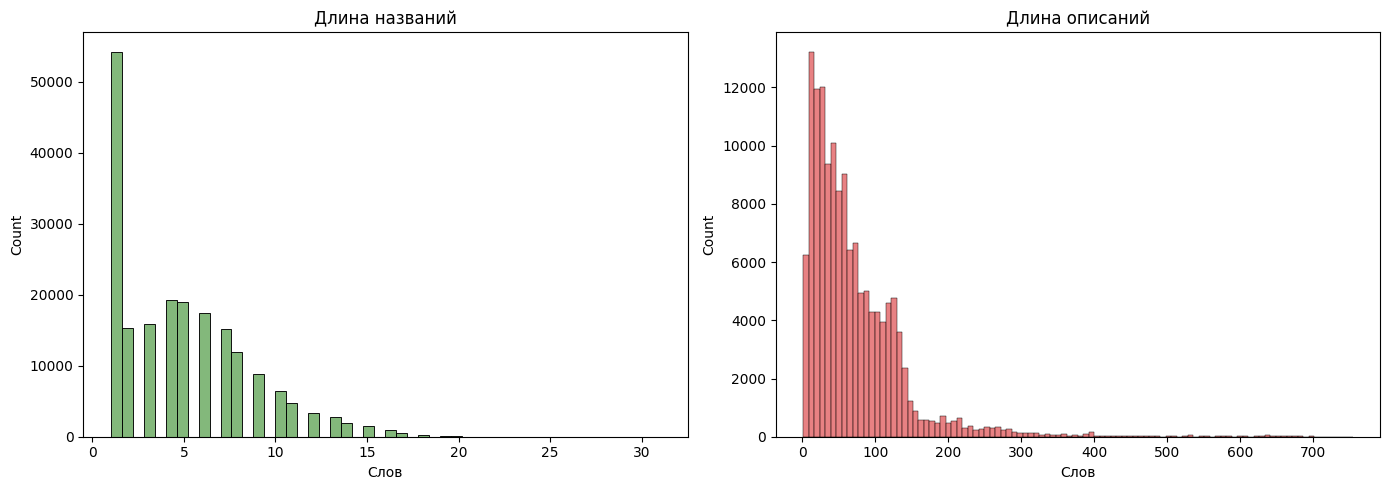

,imt_id,nm_id,imt_name,subj_name,description_words,description
58042,10051447,14195376,Кружка детская Щенячий патруль,Кружки,754.0,Представляем вашему вниманию детские лицензион...
78523,10070406,13447264,Искусственные цветы орхидея в кашпо в подарок ...,Искусственные растения,714.0,Искусственные цветы в горшке - это прекрасное ...
78524,10070406,13499670,Искусственные цветы орхидея в кашпо в подарок ...,Искусственные растения,714.0,Искусственные цветы в горшке - это прекрасное ...
127198,10115260,13508539,Панама детская для мальчиков,Панамы для малышей,713.0,Летняя панамка для маленьких малышей. Отлично ...
127199,10115260,13508540,Панама детская для мальчиков,Панамы для малышей,713.0,Летняя панамка для маленьких малышей. Отлично ...
127200,10115260,13508541,Панама детская для мальчиков,Панамы для малышей,713.0,Летняя панамка для маленьких малышей. Отлично ...
127201,10115260,13508543,Панама детская для мальчиков,Панамы для малышей,713.0,Летняя панамка для маленьких малышей. Отлично ...
94419,10085848,13467796,Щетка для посуды бутылок швабра с длинной ручкой,Щетки кухонные,711.0,"Комплект для уборки: 1 щетка , 3 губки. Щетка ..."
132091,10119657,13514494,Туфли кожаные мужские туфли натуральная кожа к...,Туфли,704.0,Классические кожаные мужские туфли Fortuna cla...
26830,10024190,13383641,Шляпа женская пляжная летняя канотье соломенная,Шляпы,701.0,Женская шляпа пляжная – необходимый аксессуар ...


In [6]:
name_lengths = text_length_profile(products_raw['imt_name'])
description_lengths = text_length_profile(products_raw['description'])
display(pd.concat({'imt_name': name_lengths, 'description': description_lengths}))

length_frame = pd.DataFrame({
    'imt_name_words': as_clean_string(products_raw['imt_name']).str.findall(r'\S+').str.len(),
    'description_words': as_clean_string(products_raw['description']).str.findall(r'\S+').str.len(),
}).apply(pd.to_numeric, errors='coerce')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(length_frame['imt_name_words'].dropna(), bins=50, ax=axes[0], color='#59A14F')
sns.histplot(length_frame['description_words'].dropna(), bins=100, ax=axes[1], color='#E15759')
axes[0].set(title='Длина названий', xlabel='Слов'); axes[1].set(title='Длина описаний', xlabel='Слов')
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'text_lengths_words.png', dpi=150, bbox_inches='tight')
plt.show()

longest_descriptions = (
    products_raw.assign(description_words=length_frame['description_words'])
    .nlargest(20, 'description_words')[['imt_id', 'nm_id', 'imt_name', 'subj_name', 'description_words', 'description']]
)
display(longest_descriptions)


**Вывод по `name_lengths`, `description_lengths` и `longest_descriptions`.** Медианное описание содержит 53 слова и 398 символов, но 1% самых длинных описаний превышает 321 слово и 2 353 символа, максимум — 754 слова и 5 000 символов. При выборе эмбеддера на следующей неделе нужно явно сопоставить этот хвост с лимитом токенов и зафиксировать политику обрезки.

## 6. Ручная проверка и диагностические признаки текста

Ниже выводятся 30 карточек с фиксированным seed и отдельные кандидаты на HTML, необычные символы и служебные токены. Автоматические флаги не являются решением об очистке: они сокращают область ручной проверки.

In [7]:
manual_review_columns = ['imt_id', 'nm_id', 'imt_name', 'subj_root_name', 'subj_name', 'brand_name', 'nm_colors_names', 'description']
manual_sample = products_raw[manual_review_columns].sample(n=min(30, len(products_raw)), random_state=SEED)
manual_review_path = ARTIFACT_DIR / 'manual_review_cards.html'
manual_sample.to_html(manual_review_path, index=False, escape=True)
assert len(manual_sample) == min(30, len(products_raw))
print(f'Full manual sample ({len(manual_sample)} cards): {manual_review_path}')
display(manual_sample[['imt_id', 'nm_id', 'imt_name', 'subj_root_name', 'subj_name']])
manual_observation_examples = manual_sample.iloc[[0, 4, 5]]
display(HTML(manual_observation_examples.to_html(index=False, escape=True)))

text_diagnostics = pd.DataFrame({
    'html_in_description': contains_html(products_raw['description']),
    'special_symbols_in_name': contains_special_symbols(products_raw['imt_name']),
    'article_like_token_in_name': contains_article_like_token(products_raw['imt_name']),
})
display(text_diagnostics.agg(['sum', 'mean']).T.rename(columns={'sum': 'count', 'mean': 'share'}).style.format({'share': '{:.2%}'}))
diagnostic_examples = products_raw.loc[text_diagnostics.any(axis=1), manual_review_columns].head(30)
display(diagnostic_examples)

preview_rows = products_raw[manual_review_columns].sample(n=min(10, len(products_raw)), random_state=SEED).copy()
preview_rows['product_text_preview'] = diagnostic_product_text(preview_rows)
artifact_pattern = r'(?:^| \. )(?:None|nan)(?: \. |$)'
assert not preview_rows['product_text_preview'].str.contains(artifact_pattern, case=False, regex=True).any()
display(preview_rows[['imt_id', 'imt_name', 'subj_name', 'description', 'product_text_preview']])


Full manual sample (30 cards): /Users/dkunicyn/Documents/to-future/calm-fruit/artifacts/eda/manual_review_cards.html


,imt_id,nm_id,imt_name,subj_root_name,subj_name
119737,10108023,6277206,Набор гель-блестки для тела с кисточкой,Красота,Глиттеры
72272,10064796,13439504,Пирсинг для пупка серебро 925 проба,Ювелирные украшения,Ювелирный пирсинг
158154,10147294,13550892,Чехол на Samsung Galaxy M21 / M30s / M31,Смартфоны и аксессуары,Чехлы для телефонов
65426,10058577,13430914,Набор стикеров Аниме Naruto (Наруто),Канцелярские товары,Стикеры
30074,10027164,13388001,Контактные линзы Pure Vision 2 (6 линз) R 8.6 ...,Здоровье,Контактные линзы
23677,10021271,13379371,"Головка 1/2"" DR со вставкой TORX T70 длиной 10...",Строительные инструменты,Головки торцевые
134858,10126692,13522489,"Сумка для ноутбука 13.3"" с косметичкой",Аксессуары,Сумки для ноутбуков
176418,10163716,13572673,Чехол на XIAOMI 9T / Силиконовый Матовый Проти...,Смартфоны и аксессуары,Чехлы для телефонов
132467,10120372,13515423,Спортивные брюки,Одежда,Брюки
4082,10003470,13354698,Чехол для телефона,Смартфоны и аксессуары,Чехлы для телефонов


imt_id,nm_id,imt_name,subj_root_name,subj_name,brand_name,nm_colors_names,description
10108023,6277206,Набор гель-блестки для тела с кисточкой,Красота,Глиттеры,LUKKY,"глубокий пурпурный, синий","Lucky набор гель-блестки д тела/лица х3 шт + кисточка, цвета: синий, серебро, пурпур, на блистере."
10027164,13388001,Контактные линзы Pure Vision 2 (6 линз) R 8.6 D -6.00,Здоровье,Контактные линзы,Bausch+Lomb,,"В этих одномесячных линзах идеально сочетаются высокая четкость зрения и гарантированный комфорт. Они идеально корригируют зрение с утра до самого вечера: даже в темное время Вы сможете ясно видеть все вокруг, а изображение будет четким и контрастным, избавленным от ореолов и бликов. Контактные линзы PureVision 2 HD необычайно тонки - всего 0,07 мм, а их края имеют немного закругленную форму - за счет этого линзы совершенно не чувствуются на глазах и незаметны даже для Вас самих. Кислородопроницаемость PureVision 2 HD довольно высока - на протяжении 24 часов они обеспечивают свободный доступ кислорода к поверхности глаза, поэтому носить их чрезвычайно комфортно и удобно."
10021271,13379371,"Головка 1/2"" DR со вставкой TORX T70 длиной 100мм (AT-BS-31)",Строительные инструменты,Головки торцевые,Airline,,"Инструменты соответствуют высоким стандартам качества, поэтому подойдут как для использования на бытовом уровне, так и для применения в профессиональной сфере.\nИнструменты изготовлены из высококачественной хром-ванадиевой стали. Металлические части изготовлены методом горячей ковки, что придаёт им высокую прочность и долговечность. Финишное прочное хромированное покрытие защищает Инструмент от воздействия коррозии, делает его более износостойким и легко очищается от загрязнений. Финишная обработка двух типов (частичная полировка) головок придаёт им отличный внешний вид."


,count,share
html_in_description,22.000000,0.01%
special_symbols_in_name,26546.000000,13.27%
article_like_token_in_name,14888.000000,7.44%


,imt_id,nm_id,imt_name,subj_root_name,subj_name,brand_name,nm_colors_names,description
13,10000007,13349985,Разогревающее и успокаивающее средство для тел...,Красота,Масла,Sri Sri Tattva,,Vedantaka Liniment - это уникальная травяная ф...
53,10000043,13350025,Бриджи/большие размеры/стрейч/ажур,Одежда,Бриджи,LAFEI-NIER,бежевый,Бриджи стрейч с ажуром из хлопка
54,10000043,13572515,Бриджи/большие размеры/стрейч/ажур,Одежда,Бриджи,LAFEI-NIER,белый,Бриджи стрейч с ажуром из хлопка
57,10000046,13350027,Жакет/приталенный /большие размеры,Одежда,Жакеты,LAFEI-NIER,голубой,Классический приталенный пиджак из стрейч ткан...
96,10000077,13350068,Фитон Крым / Крымский бальзам Заживляющий 15 г,Красота,Бальзамы,Фитон Крым,,"Крымский бальзам ""От варикоза"" используют при ..."
112,100000900,12675114,"Комплект постельного белья, БЯЗЬ, 2,0-спальное",Дом,Постельное белье,Лаванда-текс,"сиреневый, светло-фиолетовый",Постельное белье 2 спальное из ткани Бязь. Дан...
113,100000900,12997964,"Комплект постельного белья 2,0-спальный",Дом,Постельное белье,Лаванда-текс,"голубой, сиреневый, розовый, фиолетовый",Постельное белье 2 спальное из ткани Бязь. Дан...
114,100000900,12997984,"Комплект постельного белья, БЯЗЬ, 2,0-спальный",Дом,Постельное белье,Лаванда-текс,белый,Постельное белье 2 спальное из ткани Бязь. Дан...
134,10000106,13350092,"Телевизор QE49LS01TBUXRU, 49"", UHD, Smart TV, ...",Телевизоры и аудиотехника,Телевизоры,Samsung,голубой,Телевизор The Serif прекрасен со всех сторон. ...
135,10000107,13350093,"Телевизор QE65Q80TAUXRU, 65"", UHD, Smart TV, W...",Телевизоры и аудиотехника,Телевизоры,Samsung,серебристый,Телевизор LED Samsung QE65Q80TAUXRU представле...


,imt_id,imt_name,subj_name,description,product_text_preview
119737,10108023,Набор гель-блестки для тела с кисточкой,Глиттеры,Lucky набор гель-блестки д тела/лица х3 шт + к...,Набор гель-блестки для тела с кисточкой . Глит...
72272,10064796,Пирсинг для пупка серебро 925 проба,Ювелирный пирсинг,Изделие выполнено из серебра 925 пробы; покрыт...,Пирсинг для пупка серебро 925 проба . Ювелирны...
158154,10147294,Чехол на Samsung Galaxy M21 / M30s / M31,Чехлы для телефонов,Противоударный чехол отлично защищает смартфон...,Чехол на Samsung Galaxy M21 / M30s / M31 . Чех...
65426,10058577,Набор стикеров Аниме Naruto (Наруто),Стикеры,В набор входит 63 стикера. Стикеры можно клеит...,Набор стикеров Аниме Naruto (Наруто) . Стикеры...
30074,10027164,Контактные линзы Pure Vision 2 (6 линз) R 8.6 ...,Контактные линзы,В этих одномесячных линзах идеально сочетаются...,Контактные линзы Pure Vision 2 (6 линз) R 8.6 ...
23677,10021271,"Головка 1/2"" DR со вставкой TORX T70 длиной 10...",Головки торцевые,Инструменты соответствуют высоким стандартам к...,"Головка 1/2"" DR со вставкой TORX T70 длиной 10..."
134858,10126692,"Сумка для ноутбука 13.3"" с косметичкой",Сумки для ноутбуков,В комплекте: Сумка для ноутбука + косметичка.\...,"Сумка для ноутбука 13.3"" с косметичкой . Сумки..."
176418,10163716,Чехол на XIAOMI 9T / Силиконовый Матовый Проти...,Чехлы для телефонов,Легкий минималистичный кейс не только украсит ...,Чехол на XIAOMI 9T / Силиконовый Матовый Проти...
132467,10120372,Спортивные брюки,Брюки,,Спортивные брюки . Брюки
4082,10003470,Чехол для телефона,Чехлы для телефонов,,Чехол для телефона . Чехлы для телефонов


**Вывод по `manual_sample`, `manual_review_cards.html`, `text_diagnostics`, `diagnostic_examples`, `preview_rows`.** В описаниях найдено 22 HTML-фрагмента; 26 546 названий (13,27%) имеют специальные символы, а 14 888 (7,44%) — кандидаты на буквенно-цифровые токены, содержащие и буквы, и цифры. Полная выборка 30 карточек сохранена в `manual_review_cards.html`: примеры `imt_id=10027164` (`R 8.6 D -6.00`) и `imt_id=10021271` (`TORX T70`, `100мм`) показывают, что часть таких токенов — смысловые характеристики, а не мусор. Поэтому очистка должна удалять HTML и нормализовать пробелы, но не вырезать технические токены без отдельного правила; `preview_rows` подтверждает отсутствие артефактов `None`/`nan`.

## 7. Бренд и цвет

Оцениваем объём брендов и нижнюю оценку покрытия цвета названием. Проверка цвета учитывает обычные русские окончания, но остаётся диагностической и требует сверки с ручной выборкой.

In [8]:
brand_values = as_clean_string(products_raw['brand_name'])
color_present = as_clean_string(products_raw['nm_colors_names']).notna()
color_in_name = color_mentioned_in_name(products_raw)
attribute_summary = pd.Series({
    'unique_nonempty_brands': brand_values.nunique(),
    'cards_with_nonempty_color': int(color_present.sum()),
    'cards_with_nonempty_name_and_color': int(color_in_name.notna().sum()),
    'color_lexically_or_inflectionally_in_name': int(color_in_name.fillna(False).sum()),
    'share_of_name_and_color_cards_covered_by_name': float(color_in_name.mean()),
}).to_frame('value')
display(attribute_summary)
display(products_raw.loc[color_in_name.fillna(False), ['imt_id', 'imt_name', 'nm_colors_names']].sample(n=min(15, int(color_in_name.fillna(False).sum())), random_state=SEED))


,value
unique_nonempty_brands,13318.000000
cards_with_nonempty_color,165774.000000
cards_with_nonempty_name_and_color,165130.000000
color_lexically_or_inflectionally_in_name,6506.000000
share_of_name_and_color_cards_covered_by_name,0.039399


,imt_id,imt_name,nm_colors_names
105496,10095680,"Подушка на стул на стул 40х35см ""Горошек"" цвет...",красный
149634,10139895,Светильник декоративный СД 2*60 Вт E27 круг бе...,белый
148568,10138930,Набор для домашнего окрашивания бровей и ресни...,графит
107043,10097011,"Сумка трансформер для мамы , темно-синяя (сумк...",темно-синий
6924,10006023,"Набор чернографитных карандашей, заточенный, 1...",черный
104948,10095195,"Керамическая накладная овальная раковина,умыва...",белый
131144,10118856,"Ремешок для часов из натуральной кожи 10 мм, ч...",черный
171473,10159458,Кофр для хранения вещей размер 28*28*13см сире...,сиреневый
189218,10175035,Сумка дорожная 78 л черная,черный
98263,10089111,"Подушка стег. ""Elegance Line"" со съемным чехло...",белый


**Вывод по `attribute_summary` и `color_in_name`.** В каталоге 13 318 непустых брендов и 165 774 строки с указанным цветом; у 165 130 из них заполнено также название. Консервативное лексико-морфологическое совпадение цвета с названием есть у 6 506 (3,94% строк с обоими полями). Для baseline цвет и бренд останутся вне `product_text`; их влияние допустимо проверять отдельным экспериментом, а не предполагать заранее.

## 8. Тренировочная разметка и связь с каталогом

Анализируем только `queries_synthetic_train.parquet`: пары запрос—товар, шкалу релевантности, число оценённых товаров на запрос, примеры запросов и покрытие ключей каталогом. Это диагностический анализ, не golden-set и не split.

In [9]:
assert queries_train['relevance'].between(0, 3).all(), 'relevance must use the 0–3 scale'
texts_per_query = queries_train.groupby('query_id')['query_text'].nunique(dropna=False)
assert texts_per_query.eq(1).all(), 'Each query_id must map to exactly one query_text'
query_pair_duplicates = int(queries_train.duplicated(['query_id', 'item_id']).sum())
items_per_query = queries_train.groupby('query_id')['item_id'].nunique().rename('rated_items_per_query')
query_inventory = pd.Series({
    'query_item_pairs': len(queries_train),
    'unique_query_id': queries_train['query_id'].nunique(),
    'unique_item_id': queries_train['item_id'].nunique(),
    'duplicate_query_item_pairs': query_pair_duplicates,
}).to_frame('value')
display(query_inventory)
display(items_per_query.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame())
display(queries_train['relevance'].value_counts(dropna=False).sort_index().rename('pairs').to_frame())
display(queries_train[['query_id', 'query_text']].drop_duplicates().sample(n=min(20, queries_train['query_id'].nunique()), random_state=SEED))

catalog_ids = pd.Index(products_raw['imt_id'].unique())
missing_catalog_item_mask = ~queries_train['item_id'].isin(catalog_ids)
query_item_coverage = pd.Series({
    'rated_item_ids_in_raw_catalog': int(queries_train['item_id'].isin(catalog_ids).sum()),
    'rated_item_ids_not_in_raw_catalog': int(missing_catalog_item_mask.sum()),
    'unique_missing_item_ids': int(queries_train.loc[missing_catalog_item_mask, 'item_id'].nunique()),
}).to_frame('value')
display(query_item_coverage)
display(queries_train.loc[missing_catalog_item_mask, ['query_id', 'query_text', 'item_id', 'relevance']].head(30))


,value
query_item_pairs,11453
unique_query_id,700
unique_item_id,2285
duplicate_query_item_pairs,0


,rated_items_per_query
count,700.000000
mean,16.361429
std,5.424150
min,1.000000
5%,7.000000
25%,14.000000
50%,16.000000
75%,19.000000
95%,26.000000
max,31.000000


,pairs
relevance,
1,9652
2,1101
3,700


,query_id,query_text
2484,SYN_000210,топы cop copine
8139,SYN_000714,худи mego as
6376,SYN_000561,бриджи зуавы
2446,SYN_000206,кожаные мокасины
5214,SYN_000450,кожаные сабо с открытым мысом
3373,SYN_000286,классические джинсовые джинсы
3746,SYN_000318,шубы натуральные на пуговицах
4678,SYN_000401,тапочки asd
4852,SYN_000414,тапочки t taccardi
5737,SYN_000505,кигуруми londe


,value
rated_item_ids_in_raw_catalog,11453
rated_item_ids_not_in_raw_catalog,0
unique_missing_item_ids,0


,query_id,query_text,item_id,relevance


**Вывод по `query_inventory`, `items_per_query`, распределению `relevance` и `query_item_coverage`.** В train 11 453 уникальные пары для 700 запросов, без повторов; медиана — 16 оценённых товаров на запрос. Шкала содержит 9 652 оценки 1, 1 101 оценки 2 и 700 оценок 3, а все `item_id` покрыты сырым каталогом. Для будущей бинарной оценки фиксируется порог `relevance >= 2`, но NDCG будет использовать исходную шкалу 0–3.

## 9. Воспроизводимый выбор домена MVP и доказательства решений

Для MVP выбираются максимум три корневые категории. Правило ранжирует их по числу уникальных train-запросов с релевантной (`relevance >= 2`) карточкой, затем по числу карточек, которые удовлетворяют строгому входному правилу, затем по названию. Это правило использует только train и полный сырой каталог.

In [10]:
RELEVANCE_THRESHOLD = 2
K_VALUES = (1, 3, 5, 10)
mvp_category_ranking = select_mvp_root_categories(
    products_raw, queries_train, relevance_threshold=RELEVANCE_THRESHOLD, top_n=3
)
assert 1 <= len(mvp_category_ranking) <= 3
assert mvp_category_ranking['subj_root_name'].is_unique
display(mvp_category_ranking)

decision_evidence = pd.DataFrame([
    {'decision': 'Indexing level', 'rule_or_value': 'One product card per imt_id'},
    {'decision': 'Required index text', 'rule_or_value': 'Nonempty imt_name AND description'},
    {'decision': 'MVP root categories', 'rule_or_value': ' | '.join(mvp_category_ranking['subj_root_name'])},
    {'decision': 'Baseline product_text fields', 'rule_or_value': 'imt_name . subj_name . description'},
    {'decision': 'Future binary relevance threshold', 'rule_or_value': f'relevance >= {RELEVANCE_THRESHOLD}'},
    {'decision': 'Future evaluation K', 'rule_or_value': str(K_VALUES)},
    {'decision': 'Future NDCG relevance scale', 'rule_or_value': 'Original relevance 0–3'},
])
display(decision_evidence)
decision_evidence.to_csv(ARTIFACT_DIR / 'week1_decision_evidence.csv', index=False)

data_quality_evidence = pd.DataFrame([
    {'check': 'strictly_indexable_share', 'value': float((name_present & description_present).mean())},
    {'check': 'full_duplicate_rows', 'value': int(products_raw.duplicated().sum())},
    {'check': 'missing_rated_item_pairs_in_raw_catalog', 'value': int((~queries_train['item_id'].isin(catalog_ids)).sum())},
])
data_quality_evidence.to_csv(ARTIFACT_DIR / 'week1_data_quality_evidence.csv', index=False)
display(data_quality_evidence)


,subj_root_name,relevant_train_query_count,indexable_imt_count
0,Одежда,489.0,14270
1,Обувь,211.0,3697


,decision,rule_or_value
0,Indexing level,One product card per imt_id
1,Required index text,Nonempty imt_name AND description
2,MVP root categories,Одежда | Обувь
3,Baseline product_text fields,imt_name . subj_name . description
4,Future binary relevance threshold,relevance >= 2
5,Future evaluation K,"(1, 3, 5, 10)"
6,Future NDCG relevance scale,Original relevance 0–3


,check,value
0,strictly_indexable_share,0.70973
1,full_duplicate_rows,0.00000
2,missing_rated_item_pairs_in_raw_catalog,0.00000


### Сравнение вариантов `product_text`

Сравниваем три осмысленные конфигурации на одних и тех же карточках, прошедших строгий входной критерий. Таблица не измеряет качество поиска — оно появится на второй неделе, — но показывает объём текстового контекста, который каждая конфигурация передаёт модели.

In [11]:
PRODUCT_TEXT_VARIANTS = {
    'name_only': ['imt_name'],
    'name_and_category': ['imt_name', 'subj_name'],
    'name_category_description': ['imt_name', 'subj_name', 'description'],
}
strict_catalog = products_raw.loc[name_present & description_present].copy()
product_text_option_rows = []
artifact_pattern = r'(?:^| \. )(?:None|nan)(?: \. |$)'
for variant, fields in PRODUCT_TEXT_VARIANTS.items():
    candidate_text = join_text_fields(strict_catalog, fields)
    candidate_word_count = candidate_text.str.findall(r'\S+').str.len().astype(float)
    assert not candidate_text.str.contains(artifact_pattern, case=False, regex=True).any()
    product_text_option_rows.append({
        'variant': variant,
        'fields': ' . '.join(fields),
        'cards': len(candidate_text),
        'median_words': candidate_word_count.median(),
        'p95_words': candidate_word_count.quantile(.95),
    })
product_text_options = pd.DataFrame(product_text_option_rows)
assert product_text_options['cards'].eq(len(strict_catalog)).all()
display(product_text_options)


,variant,fields,cards,median_words,p95_words
0,name_only,imt_name,141946,5.0,13.0
1,name_and_category,imt_name . subj_name,141946,8.0,16.0
2,name_category_description,imt_name . subj_name . description,141946,63.0,197.0


**Вывод по `mvp_category_ranking`, `decision_evidence` и `product_text_options`.** Для MVP выбраны две категории с релевантным train-покрытием: «Одежда» (489 запросов, 14 270 пригодных `imt_id`) и «Обувь» (211, 3 697). Категории без релевантных train-запросов исключены. Варианты `product_text` имеют медианную/95-процентильную длину 5/13 слов для `imt_name`, 8/16 для `imt_name + subj_name` и 63/197 для полного текста. Для baseline выбирается `imt_name . subj_name . description`: он сохраняет назначение и детали товара; длинный хвост подтверждает необходимость явно зафиксировать лимит модели и обрезку. Оценка будет использовать `K=(1, 3, 5, 10)` и порог `relevance >= 2`.

## 10. Чек-лист завершения недели

Перед заполнением фактических результатов в `semantic_search_project_workbook.md` запустите тетрадь сверху вниз в чистом kernel и подтвердите:

- выполнены все assertions и сохранены актуальные outputs;
- в workbook перенесены только наблюдения, подтверждённые таблицами/графиками этой тетради;
- зафиксированы решения об `imt_id`, пропусках, категориях и шаблоне `product_text`;
- в workbook добавлен перечень проблем для очистки следующей недели;
- тестовая разметка, golden-set, поиск и метрики не использовались.